In [10]:
from ml_enhance import load_hpc_result, compare, CorrelationFilter, FeatureImportance
from math import floor
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns
import pandas as pd
from dataclasses import dataclass
import numpy as np
import json

from matplotlib.ticker import LogLocator, ScalarFormatter

In [2]:
@dataclass
class ModelConfig:
    mean_col: str
    std_col: str
    label: str
    color: str
    marker: str = "o"
    zorder: int = 3

In [3]:
def combine_model_dfs(model_dfs: dict[str, pd.DataFrame], metric: str) -> pd.DataFrame:
    """
    Combines per-model DataFrames into a single wide DataFrame with mean/std per model.

    Args:
        model_dfs: dict mapping model name to its DataFrame.

    Returns:
        Wide DataFrame with num_samples + {name}_mean + {name}_std columns.
    """
    n_tot = 8759 # 8763 before rerun
    n_train = floor(n_tot * (4/5))
    
    agg_dfs = []
    for name, df in model_dfs.items():
        agg = (
            df.groupby("size")[metric]
            .agg(mean="mean", std="std", count="count")
            .reset_index()
            .rename(columns={
                "mean": f"{name}_mean",
                "std": f"{name}_std",
                "count": f"{name}_count",
            })
        )

        agg_dfs.append(agg)

    combined = agg_dfs[0]
    for agg in agg_dfs[1:]:
        combined = combined.merge(agg, on="size")
    
    combined.insert(1, "num_samples", combined["size"].apply(lambda size: size * n_train))

    return combined

In [4]:
def plot_size_evo(ax: plt.Axes, df: pd.DataFrame, models: list[ModelConfig]) -> None:
    for model in models:
        ax.errorbar(
            df["num_samples"],
            df[model.mean_col],
            yerr=df[model.std_col],
            fmt="none",
            ecolor=model.color,
            capsize=4,
            alpha=0.8,
            zorder=1,
        )

    for model in models:
        sns.scatterplot(
            ax=ax,
            data=df,
            x="num_samples",
            y=model.mean_col,
            color=model.color,
            s=80,
            label=model.label,
            zorder=model.zorder,
            marker=model.marker,
        )

    ax.tick_params(axis="both", labelsize=14)
    
    ax.set_xlabel("Number of training samples", fontsize=18)
    ax.set_ylabel(r"Test R$^2$", fontsize=18)

In [88]:
def remove_neg_r2(combo_df: pd.DataFrame, topo_df: pd.DataFrame, print_dropped: bool = True) -> tuple[pd.DataFrame, pd.DataFrame]:
    num_negs_combo = set(combo_df.index[combo_df["test_r2"] < 0])
    num_negs_topo = set(topo_df.index[topo_df["test_r2"] < 0])

    combo_neg_nums = list(num_negs_combo)
    topo_neg_nums = list(num_negs_topo)

    if print_dropped:
        for fold_id, size in combo_df.loc[neg_nums, ["fold_id", "size"]].values:
            print(f"Sample with {fold_id = :.0f} and {size = :.2f} was dropped due to negative 'test_r2'.")

    return combo_df.drop(combo_neg_nums), topo_df.drop(topo_neg_nums)

In [89]:
HuberReg_combo_df = load_hpc_result(Path("../data/HuberReg_results/2_HuberReg_combo_rerun_results.pkl"), "HuberReg_topo+QM", id_as_index=False)
HuberReg_topo_df = load_hpc_result(Path("../data/HuberReg_results/2_HuberReg_topo_rerun_results.pkl"), "HuberReg_topo", id_as_index=False)
HuberReg_combo_df_pos, HuberReg_topo_df_pos = remove_neg_r2(HuberReg_combo_df, HuberReg_topo_df, print_dropped=False)


KRR_combo_df = load_hpc_result(Path("../data/KRR_results/2_KRR_combo_rerun_results.pkl"), "KRR_topo+QM", id_as_index=False)
KRR_topo_df = load_hpc_result(Path("../data/KRR_results/2_KRR_topo_rerun_results.pkl"), "KRR_topo", id_as_index=False)
KRR_combo_df_pos, KRR_topo_df_pos = remove_neg_r2(KRR_combo_df, KRR_topo_df, print_dropped=False)


chemprop_baseline_df = pd.read_json("../data/chemprop_results/2_chemprop_no_added_w_charge_rerun_results.json")
chemprop_rdkit_df = pd.read_json("../data/chemprop_results/2_chemprop_w_rdkit_rerun_results.json")
chemprop_atom_df = pd.read_json("../data/chemprop_results/2_chemprop_atom_feat_rerun_results.json")
chemprop_mol_df = pd.read_json("../data/chemprop_results/2_chemprop_mol_feat_rerun_results.json")
chemprop_full_df = pd.read_json("../data/chemprop_results/2_chemprop_full_feat_rerun_results.json")

       KRR_combo_mean  KRR_combo_std  KRR_combo_count  KRR_topo_mean  \
size                                                                   
0.025        0.703872       0.037015               19       0.694424   
0.050        0.741804       0.028706               21       0.739513   
0.075        0.772807       0.017737               23       0.762002   
0.100        0.790296       0.015940               24       0.757532   
0.150        0.804137       0.014105               24       0.801854   
0.200        0.814124       0.011201               25       0.812895   
0.250        0.824665       0.010462               25       0.821414   
0.500        0.845941       0.008842               25       0.844098   
0.600        0.851920       0.007704               25       0.849239   
0.750        0.858570       0.008794               25       0.855052   
0.900        0.863425       0.009023               25       0.859545   
1.000        0.866106       0.008672               25       0.86

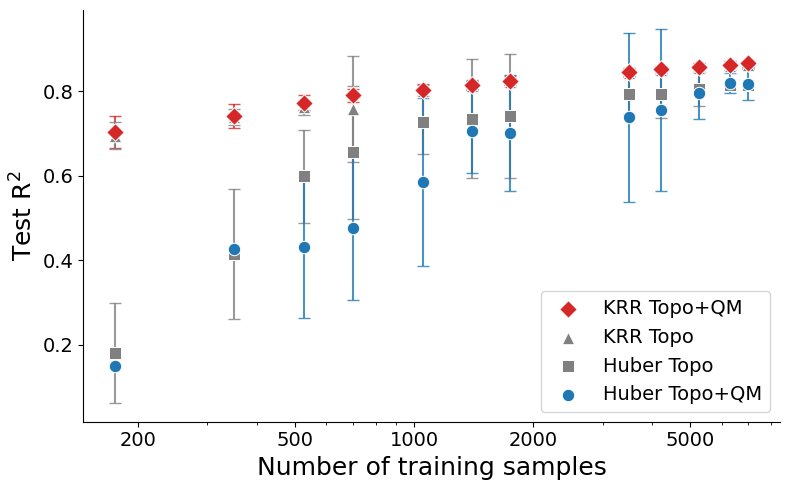

In [143]:
model_dfs = {
    "KRR_combo": KRR_combo_df_pos,
    "KRR_topo":  KRR_topo_df_pos,
    "HuberReg_topo":  HuberReg_topo_df_pos,
    "HuberReg_combo": HuberReg_combo_df_pos,
    
}

combined_df = combine_model_dfs(model_dfs, "test_r2")
print(combined_df.filter(regex=r"size|KRR", axis=1).set_index(r"size"))

models = [
    ModelConfig(mean_col="KRR_combo_mean", std_col="KRR_combo_std", label="KRR Topo+QM", color="tab:red", marker="D", zorder=4),
    ModelConfig(mean_col="KRR_topo_mean", std_col="KRR_topo_std", label="KRR Topo", color="grey", marker="^", zorder=3),
    ModelConfig(mean_col="HuberReg_topo_mean", std_col="HuberReg_topo_std", label="Huber Topo", color="grey", marker="s", zorder=1),
    ModelConfig(mean_col="HuberReg_combo_mean", std_col="HuberReg_combo_std", label="Huber Topo+QM", color="tab:blue", zorder=2),
]


fig, ax = plt.subplots(figsize=(8, 5))

plot_size_evo(ax, combined_df, models)

ax.set_xscale("log")
ax.xaxis.set_major_locator(LogLocator(subs=[1, 2, 5]))
ax.xaxis.set_major_formatter(ScalarFormatter())

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# plt.ylim(-1, 1)

ax.legend(fontsize=14)
plt.tight_layout()
# plt.savefig("score_evolution_classical.pdf", format="pdf")
plt.show()

In [ ]:
# chemprop_baseline_df["RMSE"] = chemprop_baseline_df["mse_test"].apply(np.sqrt)
# chemprop_mol_df["RMSE"] = chemprop_mol_df["mse_test"].apply(np.sqrt)
# chemprop_atom_df["RMSE"] = chemprop_atom_df["mse_test"].apply(np.sqrt)
# chemprop_full_df["RMSE"] = chemprop_full_df["mse_test"].apply(np.sqrt)
# chemprop_rdkit_df["RMSE"] = chemprop_rdkit_df["mse_test"].apply(np.sqrt)

\begin{tabular}{lrrrrrr}
\toprule
 & chemprop_atom_mean & chemprop_atom_std & chemprop_atom_count & chemprop_full_mean & chemprop_full_std & chemprop_full_count \\
size &  &  &  &  &  &  \\
\midrule
0.025000 & 0.694783 & 0.020435 & 25 & 0.662150 & 0.107140 & 23 \\
0.050000 & 0.735835 & 0.021259 & 25 & 0.720469 & 0.055909 & 24 \\
0.075000 & 0.754571 & 0.017901 & 25 & 0.758381 & 0.027853 & 24 \\
0.100000 & 0.770599 & 0.016170 & 25 & 0.760652 & 0.052419 & 25 \\
0.150000 & 0.790352 & 0.015678 & 25 & 0.792364 & 0.021672 & 25 \\
0.200000 & 0.794421 & 0.029096 & 25 & 0.798851 & 0.035134 & 25 \\
0.250000 & 0.807069 & 0.016009 & 25 & 0.787560 & 0.132581 & 25 \\
0.500000 & 0.830621 & 0.016233 & 25 & 0.831479 & 0.029032 & 25 \\
0.600000 & 0.837754 & 0.016640 & 25 & 0.843172 & 0.012623 & 25 \\
0.750000 & 0.844202 & 0.007727 & 25 & 0.847831 & 0.012831 & 25 \\
0.900000 & 0.850703 & 0.007937 & 25 & 0.855363 & 0.011162 & 25 \\
1.000000 & 0.855097 & 0.006786 & 25 & 0.857758 & 0.009114 & 25 \\
\bottomru

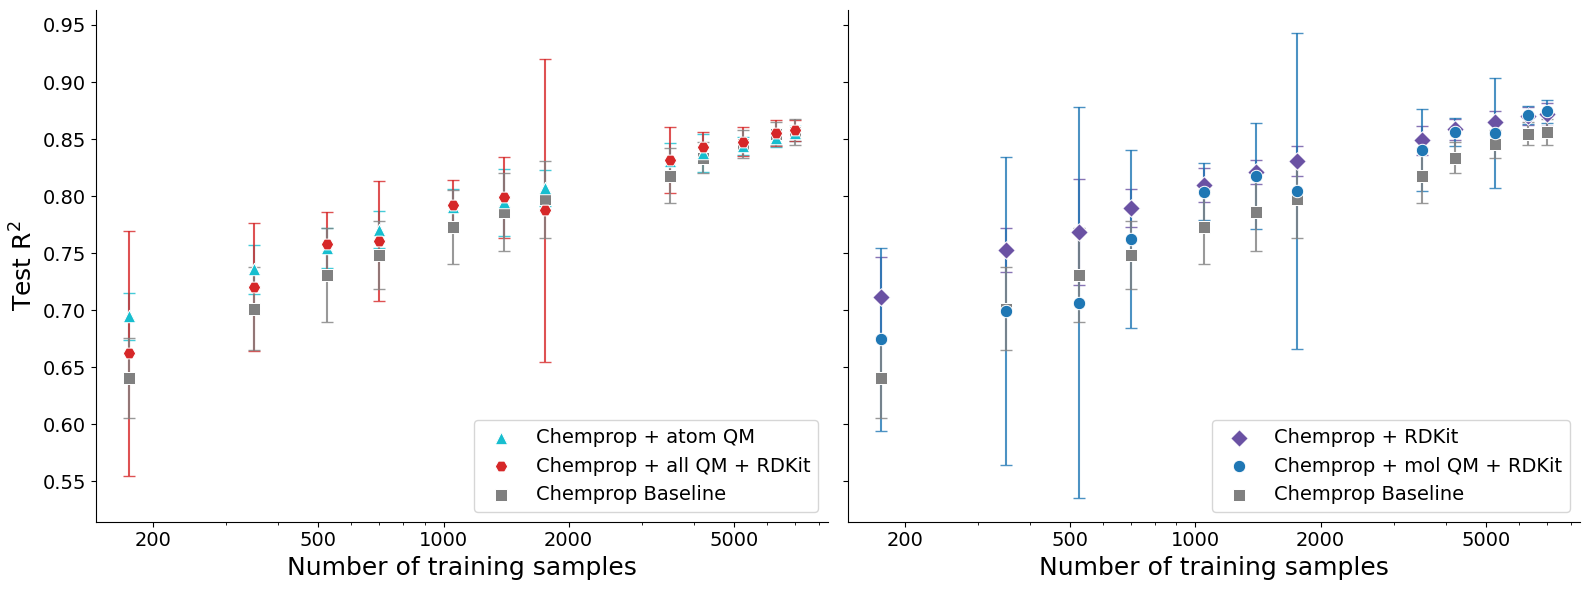

In [109]:
model_dfs = {
    "chemprop_baseline":  chemprop_baseline_df[chemprop_baseline_df["r2_test"] > 0],
    "chemprop_rdkit": chemprop_rdkit_df[chemprop_rdkit_df["r2_test"] > 0],
    "chemprop_atom":  chemprop_atom_df[chemprop_atom_df["r2_test"] > 0],
    "chemprop_mol":  chemprop_mol_df[chemprop_mol_df["r2_test"] > 0],
    "chemprop_full": chemprop_full_df[chemprop_full_df["r2_test"] > 0],   
}

combined_df = combine_model_dfs(model_dfs, "r2_test")

# display(combined_df[["size", "chemprop_baseline_mean", "chemprop_baseline_std", "chemprop_rdkit_mean", "chemprop_rdkit_std", "chemprop_atom_mean", "chemprop_atom_std", "chemprop_full_mean", "chemprop_full_std"]])
print(combined_df.filter(regex="size|atom|full", axis=1).set_index("size").to_latex())

models1 = [
    # ModelConfig(mean_col="chemprop_rdkit_mean", std_col="chemprop_rdkit_std", label="Chemprop + RDKit", color="#6a51a3", marker="D", zorder=2),
    ModelConfig(mean_col="chemprop_atom_mean", std_col="chemprop_atom_std", label="Chemprop + atom QM", color="tab:cyan", marker="^", zorder=4),
    ModelConfig(mean_col="chemprop_full_mean", std_col="chemprop_full_std", label="Chemprop + all QM + RDKit", color="tab:red", marker="H", zorder=4),
    # ModelConfig(mean_col="chemprop_mol_mean", std_col="chemprop_mol_std", label="Chemprop + mol QM + RDKit", color="tab:blue", zorder=4),
    ModelConfig(mean_col="chemprop_baseline_mean", std_col="chemprop_baseline_std", label="Chemprop Baseline", color="grey", marker="s", zorder=3),
]

models2 = [
    ModelConfig(mean_col="chemprop_rdkit_mean", std_col="chemprop_rdkit_std", label="Chemprop + RDKit", color="#6a51a3", marker="D", zorder=2),
    # ModelConfig(mean_col="chemprop_atom_mean", std_col="chemprop_atom_std", label="Chemprop + atom QM", color="tab:cyan", marker="^", zorder=4),
    # ModelConfig(mean_col="chemprop_full_mean", std_col="chemprop_full_std", label="Chemprop + all QM + RDKit", color="tab:red", marker="H", zorder=4),
    ModelConfig(mean_col="chemprop_mol_mean", std_col="chemprop_mol_std", label="Chemprop + mol QM + RDKit", color="tab:blue", zorder=4),
    ModelConfig(mean_col="chemprop_baseline_mean", std_col="chemprop_baseline_std", label="Chemprop Baseline", color="grey", marker="s", zorder=3),
]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharey=True, sharex=True)

plot_size_evo(ax1, combined_df, models1)
plot_size_evo(ax2, combined_df, models2)

ax1.set_xscale("log")
ax1.xaxis.set_major_locator(LogLocator(subs=[1, 2, 5]))
ax1.xaxis.set_major_formatter(ScalarFormatter())

ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

ax1.set_ylabel(r"Test R$^2$")

# plt.ylim(0.8, 0.9)

ax1.legend(fontsize=14, loc="lower right")
ax2.legend(fontsize=14, loc="lower right")

plt.tight_layout()
# plt.savefig("score_evolution_chemprop.pdf", format="pdf")
plt.show()

In [170]:
# from math import ceil, floor

# krr_combo_groups = KRR_combo_df_pos.groupby("size")
# krr_topo_groups = KRR_topo_df_pos.groupby("size")

# for size in KRR_plot_df.index:
#     print(f"------ {size = } ------")
#     n_tot = 8763

#     n_train = floor(floor(n_tot * 0.8) * size)
#     n_test = ceil(n_tot * 0.2)


#     compare(
#         krr_combo_groups.get_group(size).reset_index(),
#         krr_topo_groups.get_group(size).reset_index(),
#         n_train=n_train,
#         n_test=n_test
#     )

#     print("\n\n\n")

In [167]:
from ml_enhance import get_topology_features
import re

def plot(
        df, ax, num_features: int = 10, *, color: str = "tab:blue", title: str | None = None, shap: bool = False
    ) -> None:
        """Plot the feature importance on a given axis.

        params:
            ax (matplotlib.axes.Axes): axis to plot on
            num_features (int): top "n" features to plot
            color (str): color for QM features
        """
        df = df.head(num_features)

        pattern = "|".join(get_topology_features())
        topology_features = [feature for feature in df["feature"] if re.search(pattern, feature)] + [
            "in_ring?",
            "bond_type",
            "atomic_number",
            "degree",
            "number_of_hydrogens",
            "chiral_tag",
            "stereochemistry",
            "hybridization",
            "formal_charge",
            "conjugated?",
            "aromaticity",
            "mass",
            "Atomic structure",
            "Bond structure",
        ]

        colors = ["grey" if feature in topology_features else color for feature in df["feature"]]
        alphas = [0.6 if feature in topology_features else 1 for feature in df["feature"]]

        bars = ax.barh(
            df["feature"],
            df["score"].to_numpy(),
            color=colors,
            xerr=df["std_score"].to_numpy(),
            capsize=3,
        )

        for bar, alpha in zip(bars, alphas, strict=True):
            bar.set_alpha(alpha)

        # legend_elements = [
        #     Patch(facecolor=color, label="QM feature"),
        #     Patch(facecolor="grey", label="Topological feature", alpha=0.6),
        # ]

        for tick in ax.get_yticklabels():
            tick.set_size(14)
            if tick.get_text() not in topology_features:
                tick.set_fontweight("bold")
                tick.set_color(color)

        ax.invert_yaxis()
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        xlabel = "mean(|SHAP value|)" if shap else "Feature importance"
        ax.set_xlabel(xlabel, fontsize=18)
        if title is not None:
            ax.set_title(title, fontsize=20)
        # ax.legend(handles=legend_elements, frameon=False, loc="lower right", fontsize=12)

In [158]:
# KRR_combo_df[KRR_combo_df["size"] == 0.025].sort_values("fold_id")

C:\Users\thibo\AppData\Local\Temp\ipykernel_23248\846843982.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df = krr_combo_fi_df[krr_combo_fi_df["size"]==0.025][~krr_combo_fi_df["fold_id"].isin([4, 8, 11, 12, 13, 19])]
C:\Users\thibo\AppData\Local\Temp\ipykernel_23248\846843982.py:13: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


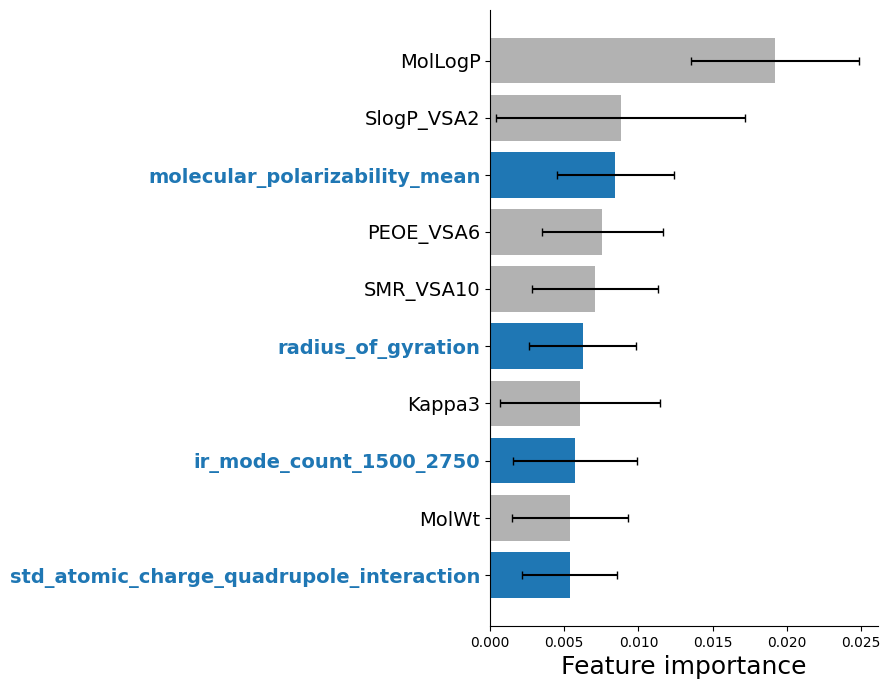

In [ ]:
file = Path(r"..\data\KRR_results\2_KRR_combo_rerun_PFI_results.csv")
krr_combo_fi_df = pd.read_csv(file)
df = krr_combo_fi_df[krr_combo_fi_df["size"]==0.025][~krr_combo_fi_df["fold_id"].isin([4, 8, 11, 12, 13, 19])]

fi_df = df.groupby("feature")["r2_mean"].agg(
    score="mean",
    std_score="std"
).sort_values(by="score", ascending=False).reset_index()

fig, ax = plt.subplots(figsize=(5, 8))

plot(fi_df, ax)
plt.tight_layout()
# plt.savefig("krr_pfi_small_dataset.pdf", format="pdf", bbox_inches='tight')
plt.show()

In [243]:
groups = {
    "Atomic structure": [
        "atomic_number",
        "mass",
        "degree",
        "number_of_hydrogens",
        "hybridization",
        "formal_charge",
        "aromaticity",
        "chiral_tag",
    ],

    "Bond structure": [
        "bond_type",
        "in_ring?",
        "conjugated?",
        "stereochemistry",
    ],

    "Electrostatics": [
        "partial_charge",
        "atomic_dipole_norm",
    ],

    "Polarizability": [
        "atomic_polarizability_mean",
        "atomic_polarizability_anisotropy",
    ],

    "Reactivity": [
        "atomic_fukui_plus",
        "atomic_fukui_minus",
    ],

    "Geometry": [
        "atomic_sasa",
        "atomic_quadrupole_principal_invariant_2",
        "atomic_quadrupole_principal_invariant_3",
        "bond_length",
        "nuclear_repulsion",
        "bond_stiffness",
        "atomic_dipole_dipole_interaction",
    ],
}

In [246]:
def get_importance(feature_set: str, input_path: Path, exclude: list[int] | None = None) -> tuple[pd.DataFrame, FeatureImportance]:
    shap_files = [file for file in input_path.glob("*SHAP*") if file.is_file()]

    combined_df = pd.DataFrame()

    for idx, file in enumerate(shap_files, start=1):
        match = re.search(r"id=(\d+)", file.stem)
        fold_id = int(match.group(1))

        if exclude is not None and fold_id in exclude:
            continue

        with file.open("r") as f:
            data = json.load(f)
        
        df = pd.DataFrame(data["shap_values"], columns=data["feature_names"]).abs()

        if feature_set != "Chemprop + RDKit":
            df.drop("formal_charge", axis=1)

        new_df = pd.DataFrame()
        for key, vals in groups.items():
            existing_cols = [col for col in vals if col in df.columns]

            if not existing_cols:
                continue

            new_df[key] = df[existing_cols].mean(axis=1)
            df = df.drop(existing_cols, axis=1)
    
        if len(df) > 0:
            new_df = pd.concat([new_df, df], axis=1)

        new_df = new_df.agg(["mean"], axis=0).T
        new_df = new_df.reset_index().rename({"index": "feature", "mean": "mean_abs_shap"}, axis=1)
        new_df.insert(0, "fold_id", idx)
        new_df.insert(1, "size", 1.0)

        combined_df = pd.concat(
            [combined_df, new_df]
        )
        
    importance = FeatureImportance(combined_df)

    importance.get_FI_from_shap(num_features=30)

    return combined_df, importance

In [247]:
chemprop_full_df.query("size == 0.025").sort_values("fold_id")

,fold_id,size,r2_test,mse_test,message_hidden_dim,depth,ffn_hidden_dim,ffn_n_layers
0,0,0.025,0.710103,0.302957,294,2,394,4
132,1,0.025,0.471852,0.587056,345,2,281,3
204,2,0.025,0.691315,0.349752,230,4,497,1
216,3,0.025,0.686014,0.352661,205,3,216,3
228,4,0.025,0.656584,0.340016,109,3,384,2
240,5,0.025,0.701700,0.348760,237,1,258,1
252,6,0.025,-4.290916,5.330285,263,4,479,1
264,7,0.025,0.687506,0.333260,185,3,156,4
276,8,0.025,0.736861,0.252362,100,3,330,2
288,9,0.025,0.647574,0.348451,253,4,458,1


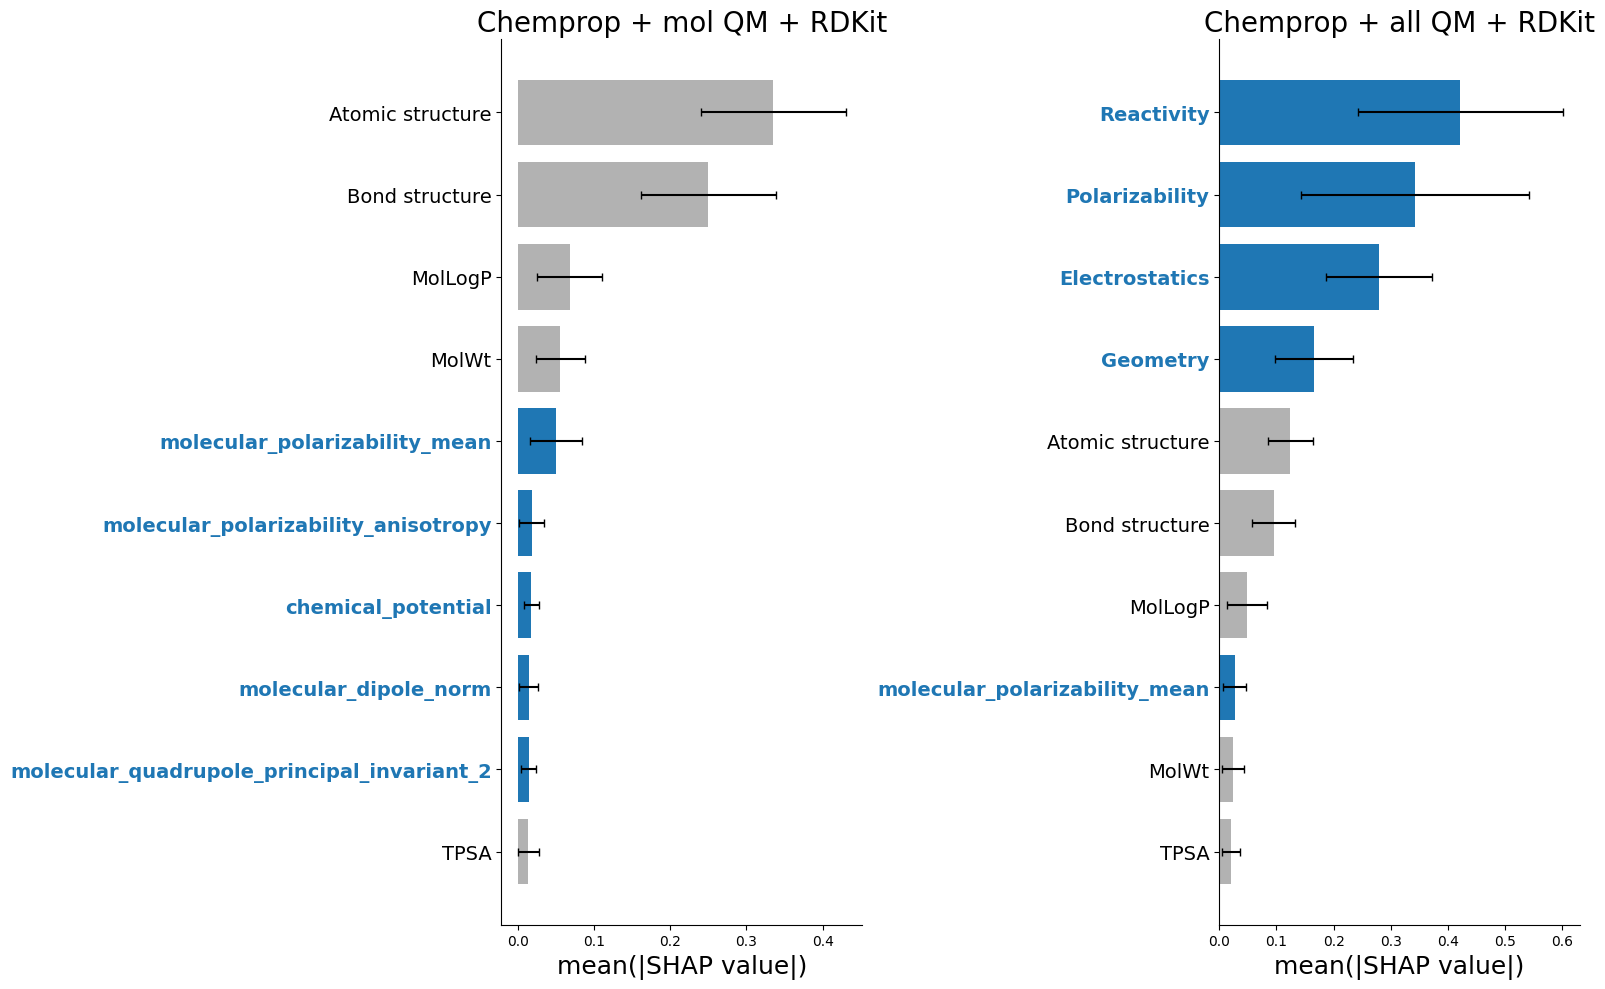

In [259]:
input_paths = {
    # "Chemprop Baseline": Path(r"C:\Users\thibo\Downloads\hpc_results\2_chemprop_no_added_w_charge_rerun"),
    # "Chemprop + RDKit": Path(r"C:\Users\thibo\Downloads\hpc_results\2_chemprop_w_rdkit_rerun"),
    # "Chemprop + atom QM": Path(r"C:\Users\thibo\Downloads\hpc_results\2_chemprop_atom_feat_rerun"),
    "Chemprop + mol QM + RDKit": Path(r"C:\Users\thibo\Downloads\hpc_results\2_chemprop_mol_feat_rerun"),
    "Chemprop + all QM + RDKit": Path(r"C:\Users\thibo\Downloads\hpc_results\2_chemprop_full_feat_rerun"),
}
fig, axes = plt.subplots(1, 2, figsize=(16, 10))

for idx, (key, input_path) in enumerate(input_paths.items()):
    # row, col = idx // 2, idx % 2

    exclude = [1, 6, 19, 22] if key == "Chemprop + mol QM + RDKit" else [6, 22] if key == "Chemprop + all QM + RDKit" else None

    df, importance = get_importance(key, input_path, exclude=exclude)

    importance.plot(axes[idx], 10, shap=True, title=key)

plt.tight_layout()
# plt.savefig("grouped_shap_obj3_app.pdf", format="pdf", bbox_inches='tight')
plt.show()